**ML COURSE 2025-2026**
# Esame - 2° Appello - 03/07/2026

**ISTRUZIONI**
- Completa **tutte le sezioni** dove trovi scritto <span style="color:red"><strong>TODO</strong></span> e <span style="color:red"><strong>Risposta</strong></span>

  
  - In alcuni casi, <span style="color:red"><strong>Risposta</strong></span> sarà all'interno di una **cella di testo**: in quel caso, dovrai rispondere **a parole** alla domanda posta.  
  
  - In altri casi, sarà all'interno di una **cella di codice**: in quel caso, dovrai completare la cella **implementando quanto richiesto**.



- **Aggiungi commenti al codice** per spiegare chiaramente cosa stai facendo. Questo passaggio è molto importante: in alcuni casi è **più importante del codice stesso**.

- Assicurati che, cliccando su **"Restart and Run All"**, il codice funzioni **senza errori**, per quanto possibile.

- **Motiva le scelte più critiche**.


In [ ]:
# AGGIUNGI I TUOI DATI
n_matricola = 000000
nome = "..."
cognome = "..."

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from exam_utils import random_train_test_split, stratified_train_test_split, accuracy, get_confusion_matrix, TP_TN_FP_FN, specificity, precision, recall

## 1. Preprocessing e Data Analysis

Il dataset contiene storici per prevedere l'area di foresta bruciata all'interno di un parco, utilizzando variabili meteorologiche e indici di rischio di incendio.

| Nome Feature          | Descrizione |
| ------------------    | ---------------------------------------------------------------------------------- |
| `area`                | **Variabile target**: area bruciata della foresta (in ha) |
| `X`                   | Coordinata x nella mappa del parco |
| `Y`                   | Coordinata y nella mappa del parco |
| `month`               | mese dell'anno |
| `day`                 | giorno dell'anno |
| `fuel_humidity`       | contenuto di umidità del combustibile superficiale (foglie, aghi, erba secca)  |
| `fuel_available`      | potenziale del combustibile presente  |
| `soil_humidity`       | contenuto umidità strato superficiale terreno  |
| `drought`             | indice di siccità del suolo|
| `propagation_speed`   | indice di velocità iniziale di propagazione incendio  |
| `temp`                | temperatura (°C) |
| `air_humidity`        | umidità relativa atmosfera |
| `wind_speed`          | velocità del vento (km/h)|
| `rain`                | quantità di pioggia (mm/m^2) |

In [2]:
data = pd.read_csv("forestfires_exam.csv")
display(data.head())

,X,Y,month,day,fuel_humidity,fuel_available,soil_humidity,drought,propagation_speed,temp,air_humidity,wind_speed,rain,area
0,7,5,mar,fri,86.2,133.358317,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,185.064268,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,160.911111,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,40.413867,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,37.135345,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


<span style="color:red"><strong>TODO 1</strong></span>

Esplora il dataset, **implementando** tecniche e visualizzazioni viste a lezione. Per ogni aspetto analizzato, **commenta** perché è utile per la costruzione di un modello di machine learning e quali possono essere le implicazioni. 

In [ ]:
# Risposta 1: 
...

In [3]:
# SOLUZIONE

# 1. Descrizione generale: ci aiuta a identificare variabili numeriche e categoriche, 
# valori mancanti, outliers e informazioni generali sulla distribuzione dei dati. 
data_summary = data.describe(include="all").transpose()
display(data_summary)
display(data.info())

target_name = "area"
feature_names = data.columns.tolist()
categorical_features = ["month", "day"]
numerical_features = [col for col in feature_names if col not in categorical_features and col != target_name]

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
X,517.0,NaN,NaN,NaN,4.669246,2.313778,1.0,3.0,4.0,7.0,9.0
Y,517.0,NaN,NaN,NaN,4.299807,1.2299,2.0,4.0,4.0,5.0,9.0
month,517,12,aug,184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day,517,7,sun,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fuel_humidity,517.0,NaN,NaN,NaN,90.644681,5.520111,18.7,90.2,91.6,92.9,96.2
fuel_available,517.0,NaN,NaN,NaN,184.087898,80.080208,0.0,138.476148,202.569545,243.551204,324.590719
soil_humidity,502.0,NaN,NaN,NaN,111.138446,63.786604,1.1,70.8,108.35,142.125,291.3
drought,517.0,NaN,NaN,NaN,547.940039,248.066192,7.9,437.7,664.2,713.9,860.6
propagation_speed,509.0,NaN,NaN,NaN,9.060511,4.577796,0.0,6.5,8.4,11.0,56.1
temp,517.0,NaN,NaN,NaN,18.889168,5.806625,2.2,15.5,19.3,22.8,33.3


<class 'pandas.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   X                  517 non-null    int64  
 1   Y                  517 non-null    int64  
 2   month              517 non-null    str    
 3   day                517 non-null    str    
 4   fuel_humidity      517 non-null    float64
 5   fuel_available     517 non-null    float64
 6   soil_humidity      502 non-null    float64
 7   drought            517 non-null    float64
 8   propagation_speed  509 non-null    float64
 9   temp               517 non-null    float64
 10  air_humidity       517 non-null    int64  
 11  wind_speed         514 non-null    float64
 12  rain               517 non-null    float64
 13  area               517 non-null    float64
dtypes: float64(9), int64(3), str(2)
memory usage: 56.7 KB


None

In [4]:
# 2. Valori mancanti: identificazione e gestione. 
missing_values_count = data.isna().sum()
print("Conteggio valori mancanti per ogni colonna:")
print(missing_values_count)

# in questo caso, dato che non sono tanti, possiamo fare imputazione con la mediana/media (numeriche)
# e con la moda (categoriche)
for col in numerical_features:
    median_value = data[col].median()
    data[col] = data[col].fillna(median_value)
for col in categorical_features:
    mode_value = data[col].mode()[0]
    data[col] = data[col].fillna(mode_value)

# count nan per assicurarsi che non ce ne siano più
nan_counts = data.isna().sum()
print("Conteggio valori mancanti dopo l'imputazione:")
print(nan_counts)

Conteggio valori mancanti per ogni colonna:
X                     0
Y                     0
month                 0
day                   0
fuel_humidity         0
fuel_available        0
soil_humidity        15
drought               0
propagation_speed     8
temp                  0
air_humidity          0
wind_speed            3
rain                  0
area                  0
dtype: int64
Conteggio valori mancanti dopo l'imputazione:
X                    0
Y                    0
month                0
day                  0
fuel_humidity        0
fuel_available       0
soil_humidity        0
drought              0
propagation_speed    0
temp                 0
air_humidity         0
wind_speed           0
rain                 0
area                 0
dtype: int64


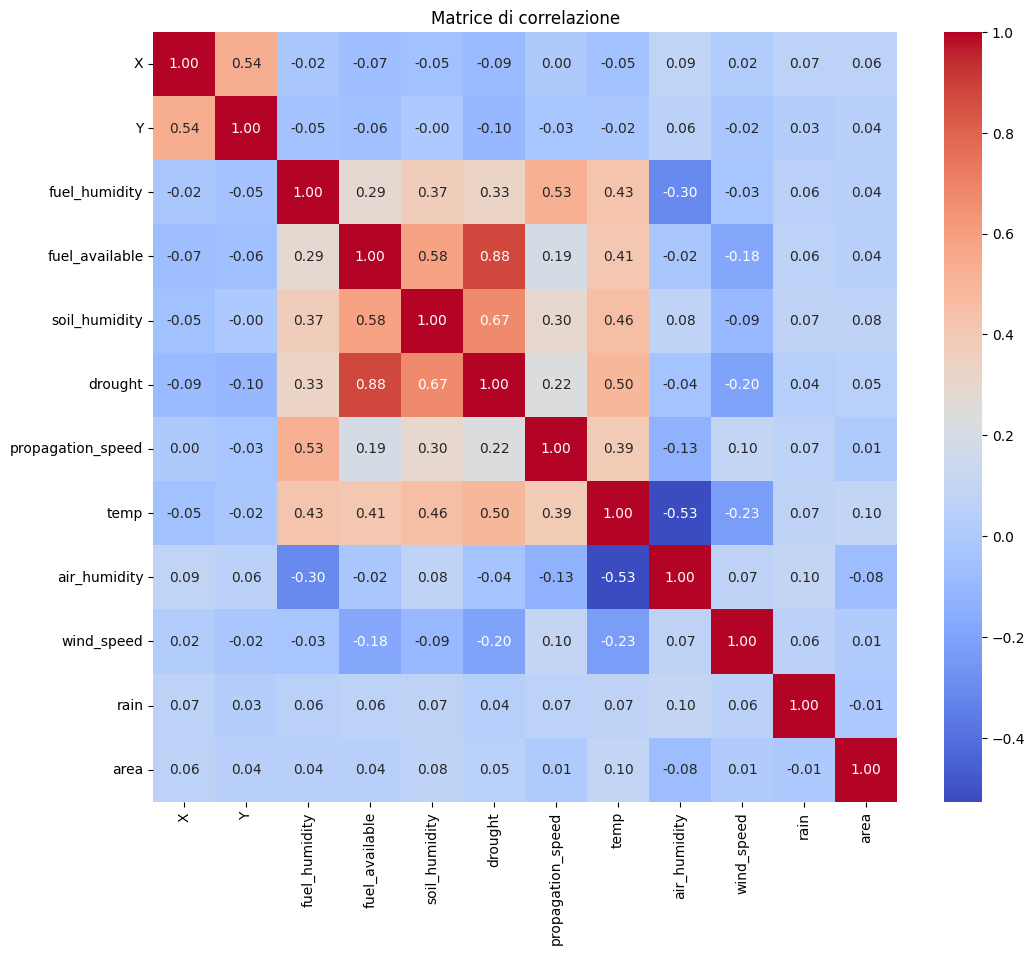

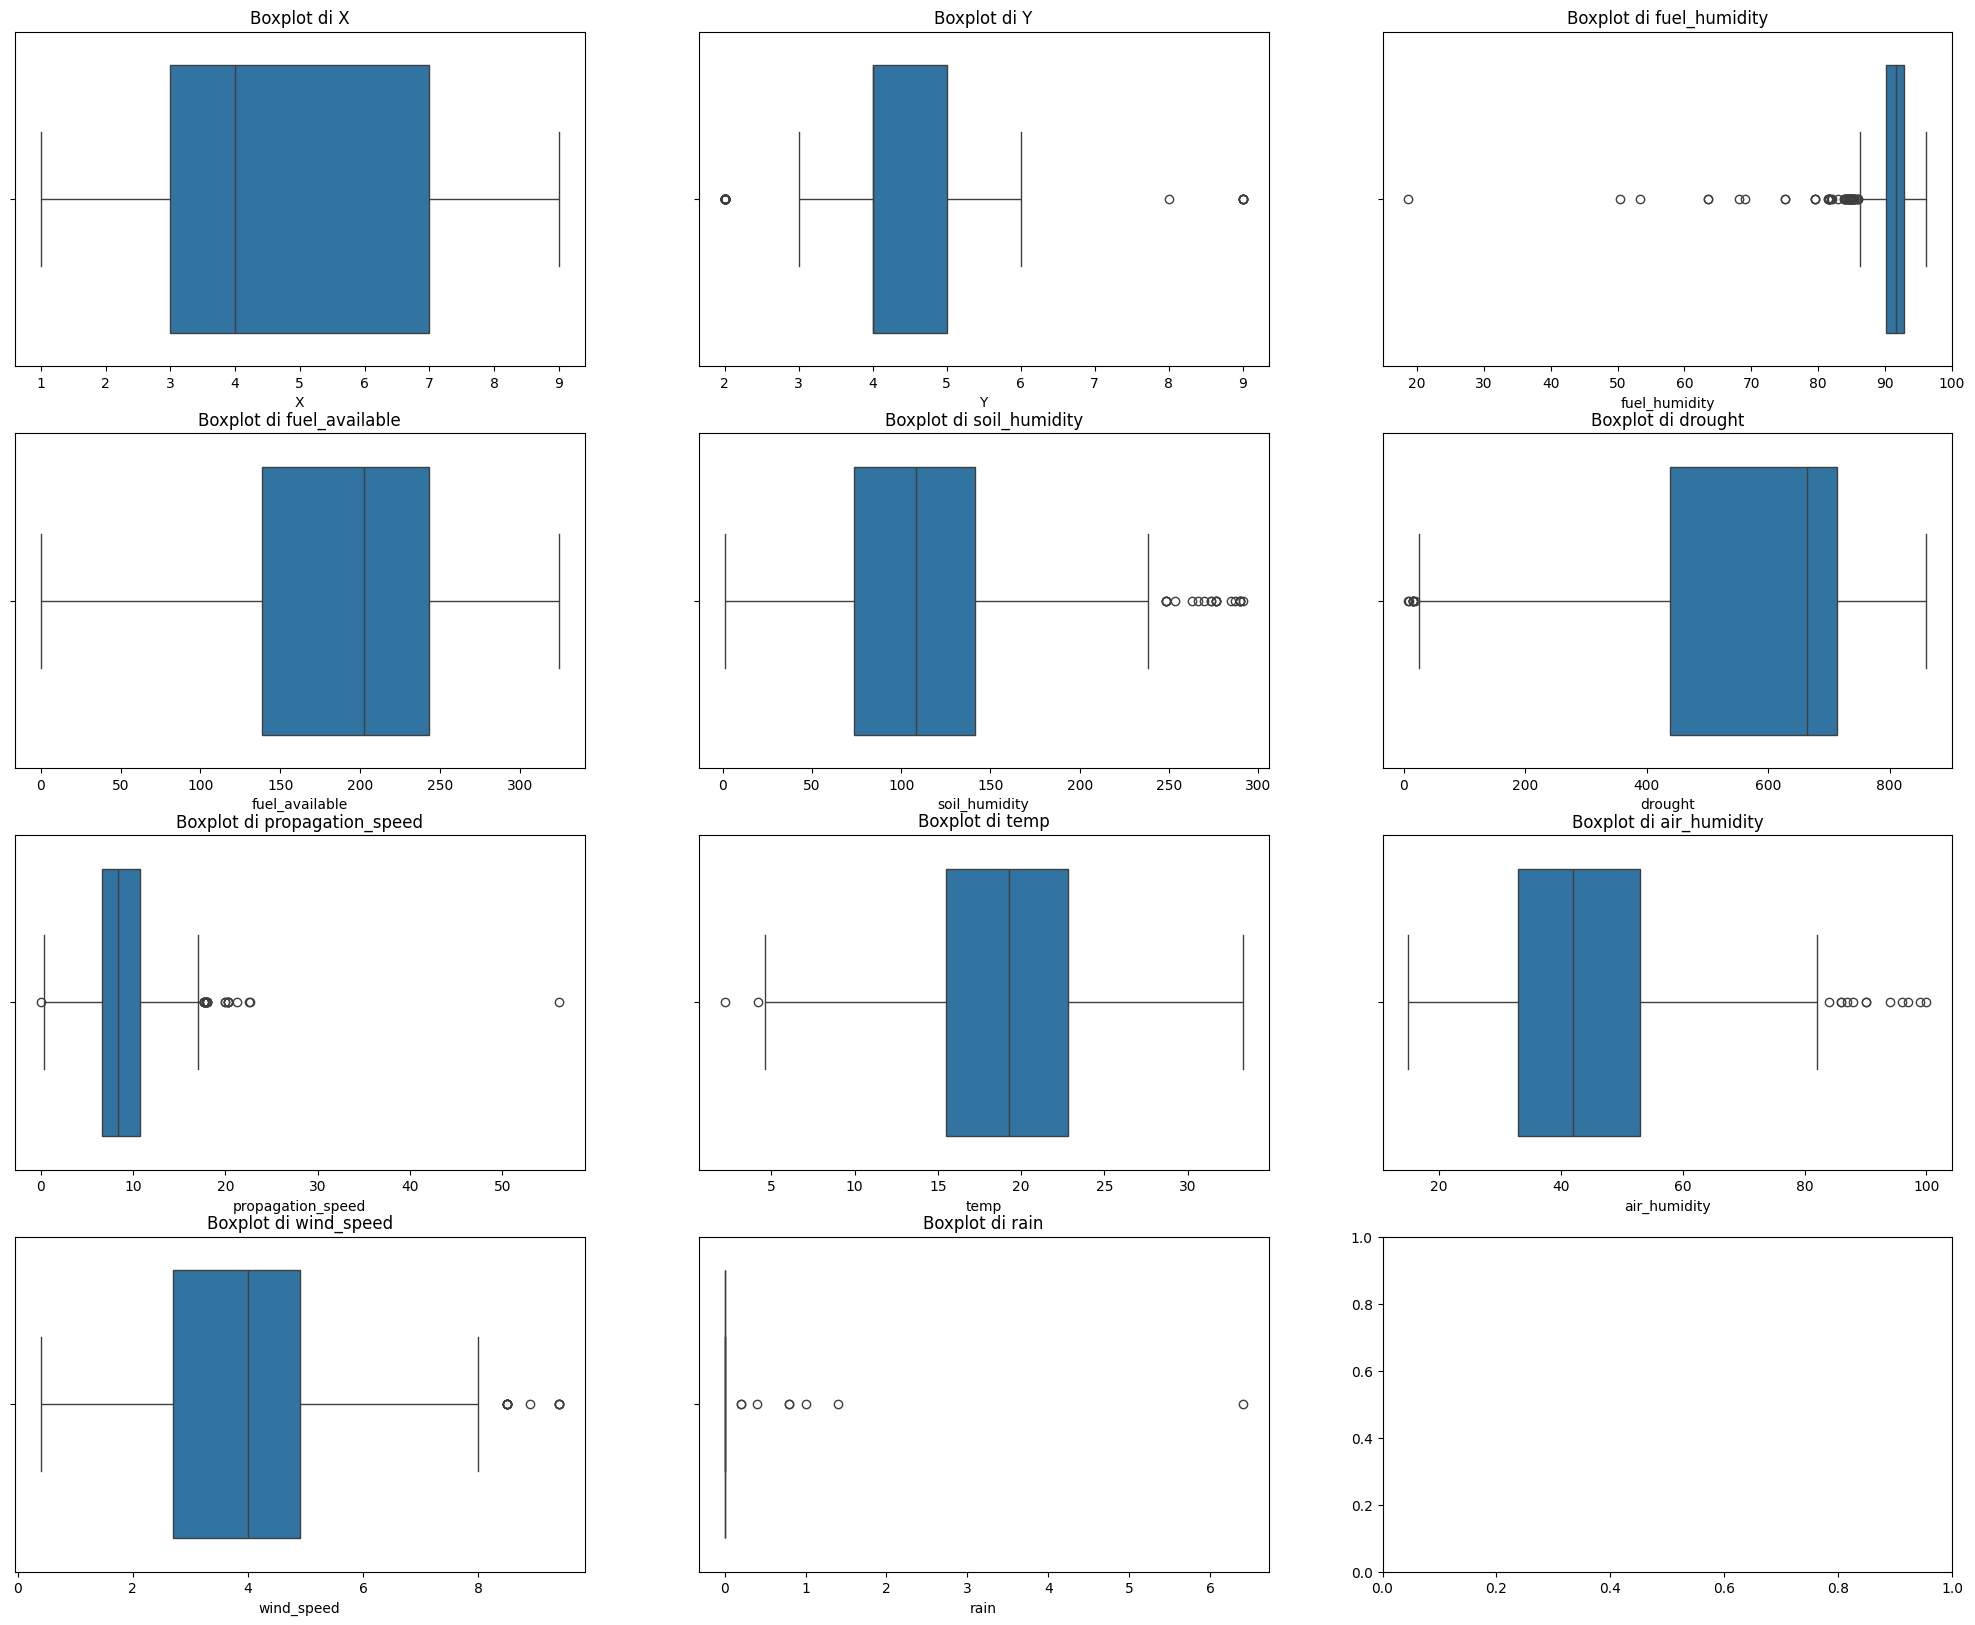

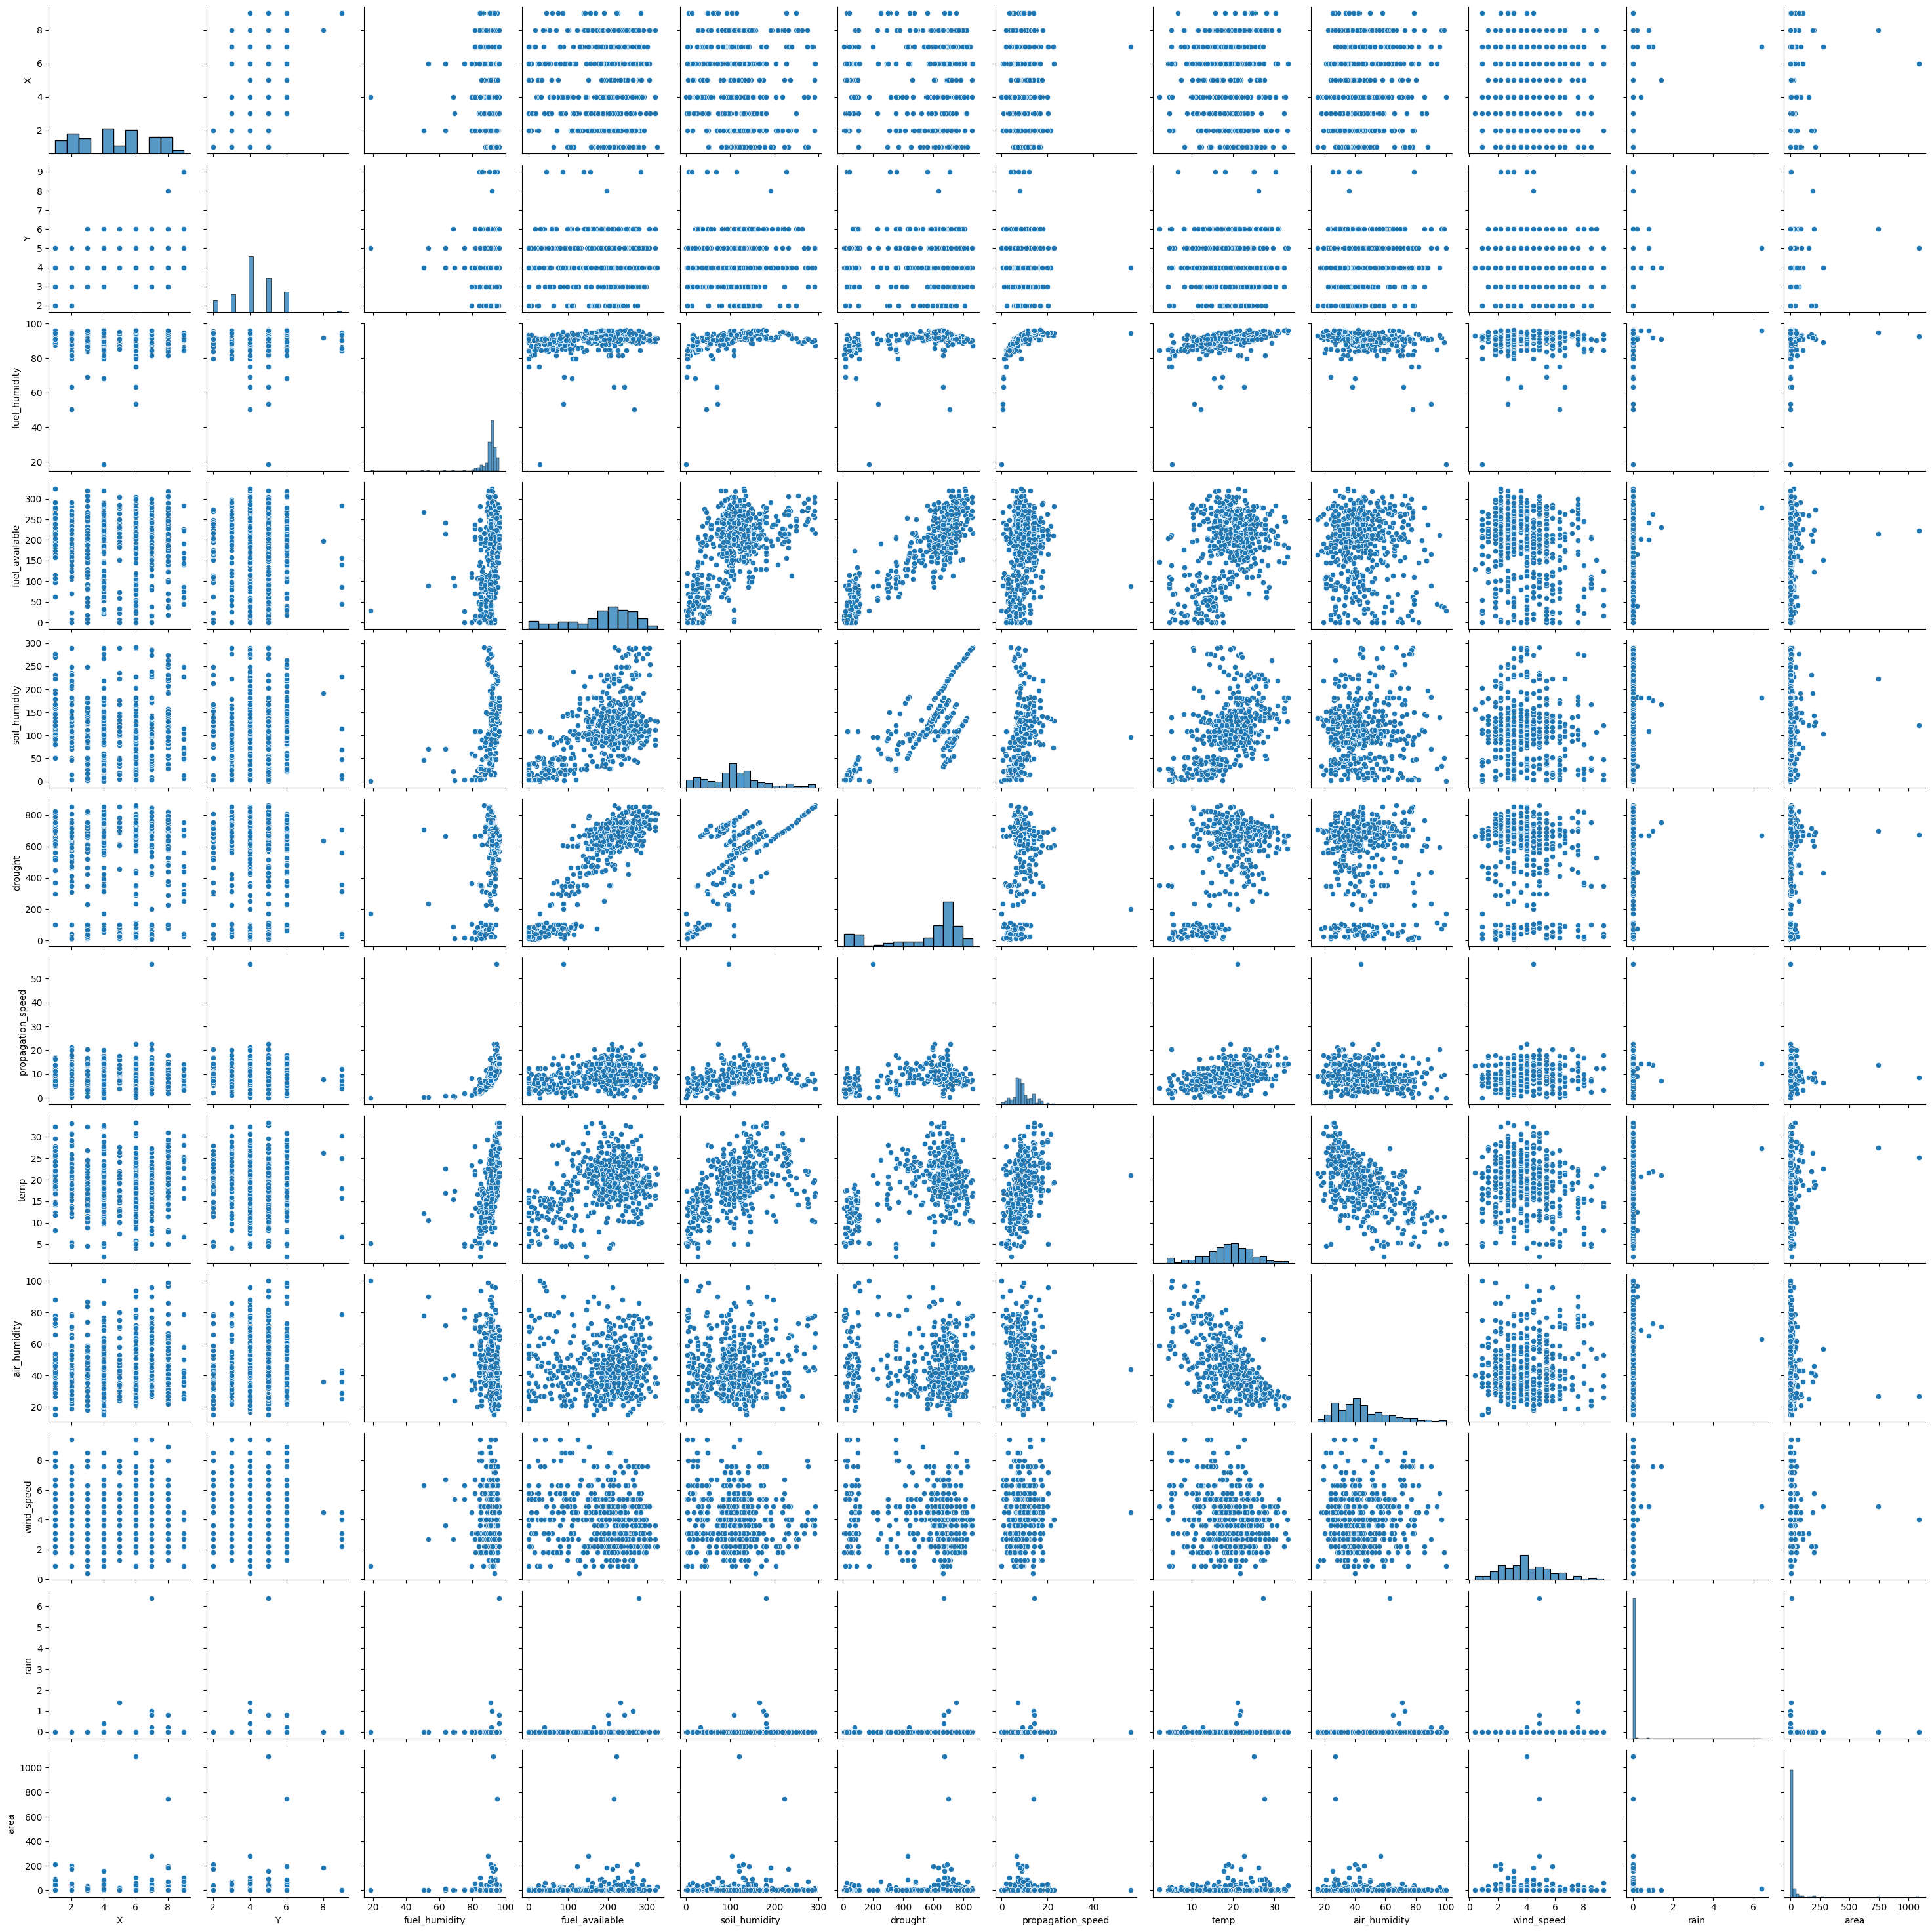

In [5]:
# 3. Analisi variabili numeriche
# 3.a correlazione tra variabili numeriche (con se stesse e target)
numerical_data = data[numerical_features + [target_name]]
correlation_matrix = numerical_data.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matrice di correlazione")
plt.show()

# alta correlazione tra fuel_available e drought. si può eliminare una feature
# ci sono anche correlazione negative tra variabili (es. air_humidity e temp)
# si nota anche che nessuna variable ha una correlazione forte con il target "area"
# quindi una regressione lineare potrebbe non essere la scelta migliore

# 3.b boxplot (per distribuzione ed outlier)
plt.subplots(4, 3, figsize=(25, 20))
for i, col in enumerate(numerical_features[:11]):
    plt.subplot(4, 3, i+1)
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot di {col}")
# in questo caso potremmo essere interessati a prevedere anche gli outlier perché potrebbero essere
# i casi più gravi, quindi eliminarli potrebbe non essere una buona idea.

# 3.c pairplot (+ istogramma): per vedere relazioni lineari tra feature-feature e feature-target. Di nuovo: non sembrano esserci relazioni lineari
# tra una singola feature e target.
sns.pairplot(numerical_data)
plt.show()


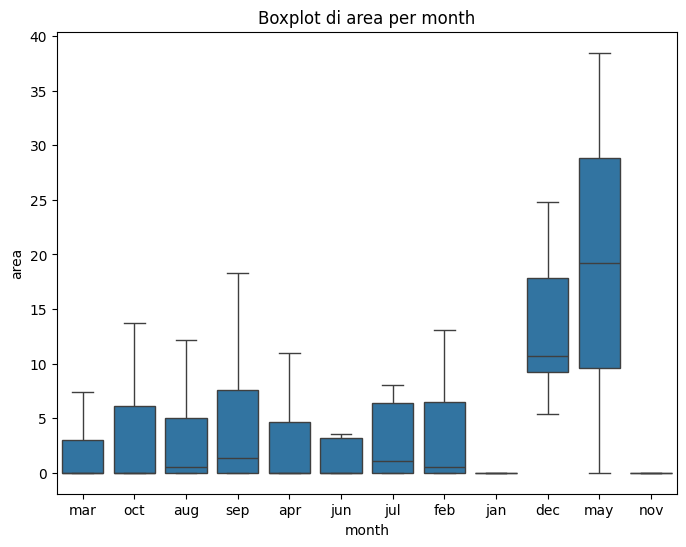

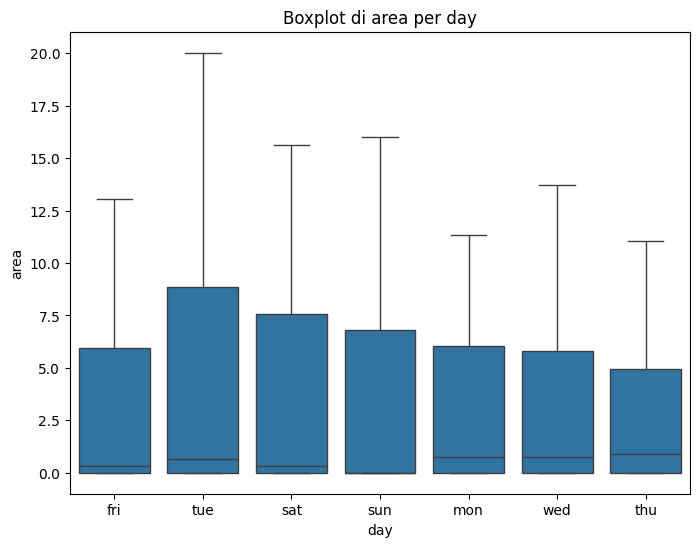

Conteggio categorie per month:
month
aug    184
sep    172
mar     54
jul     32
feb     20
jun     17
oct     15
apr      9
dec      9
jan      2
may      2
nov      1
Name: count, dtype: int64


Conteggio categorie per day:
day
sun    95
fri    85
sat    84
mon    74
tue    64
thu    61
wed    54
Name: count, dtype: int64




In [6]:
# 4. Analisi variabili categoriche

# 4.a boxplot di target per ogni categoria: per vedere se ci sono differenze evidenti tra categorie.
# togliamo gli outlier se no non capiamo bene le differenze tra categorie
for i, col in enumerate(categorical_features):
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=data[col], y=data[target_name], showfliers=False)
    plt.title(f"Boxplot di {target_name} per {col}")
    plt.show()

# il mese dell'anno ha un effetto sul target: dicembre e maggio hanno valori di area bruciata più alti. 
# il giorno della settimana non ha nessun effetto. uno potrebbe pensare di rimuovere questa feature. 

# 4.b conta quante variabili per categoria ci sono 
for col in categorical_features:
    print(f"Conteggio categorie per {col}:")
    print(data[col].value_counts())
    print("\n")
 
# la feature "month" è molto sbilanciata: ci sono tanti dati raccolti ad agosto e settembre e pochissimi a aprile, dicembre, gennaio, maggio e novembre. 
# per questi sample con feature poco rappresentate, la predizione potrebbe risultare meno accurata. 
# il fatto osservato sopra che sembra esserci un effetto di month = dec e month = may sul target potrebbe 
# essere poco affidabile, dato che ci sono pochi sample per queste categorie.

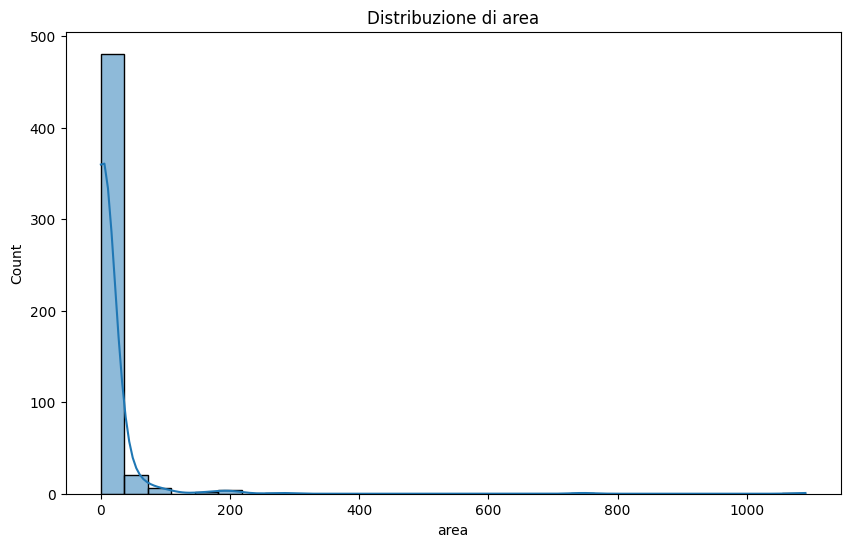

In [7]:
# 5. Analisi target
# possiamo plottare l'istogramma del target per vedere la distribuzione, e eventualmente fare trasformazioni (logaritmo, etc.) se è molto sbilanciato.
plt.figure(figsize=(10, 6))
sns.histplot(data["area"], bins=30, kde=True)
plt.title("Distribuzione di area")
plt.show()

# area presenta distribuzione molto asimmetrica a destra. questo può essere un problema per alcuni modelli di regressione 
# che tenderanno a predire meglio valori bassi e peggio valori alti. 

## 2. Modello di Machine Learning

Vogliamo usare uno smartwatch per riconoscere automaticamente se l'utente sta svolgendo attività fisica (label 0/1), usando i dati dei sensori. Ottenere le label è costoso e soggetto ad errori, mentre raccogliere dati senza etichetta no. Sono quindi disponibili: 
- un piccolo insieme di dati **etichettati** (con label) `X_train`, che però contiene etichette rumorose e/o errate.
- un grande insieme di dati **non etichettati** (senza label), `X_unlabeled`.

Per sfruttare anche i dati non etichettati si decide di adottare la seguente procedura: 
1. Usare un classificatore **KNN** usando solo i dati etichettati per predire la classe dei non etichettati (usa euclidean distance).
2. Associare a ogni predizione anche una **misura di confidenza (o probabilità)**. 
3. Usare le predizioni con alta confidenza come **pseudo-label**: aggiungere i campioni con alta confidence e le loro pseudo-label/predizioni al dataset di training. 
5. Addestrare una **logistic regression** sul dataset ottenuto. 

<span style="color:red"><strong>TODO 2</strong></span> 
- <span style="color:red"><strong>2.1</strong></span>: 
    - implementa una versione modificata di KNN tale che, oltre alla  descrivi la classe predetta, restituisca anche una misura di confidenza/probabilità della predizione. *Se non riesci, implementa solo KNN e descrivi come daresti la confidence a parole*.
    - predici la classe (e la confidence) per ogni sample in `X_unlabeled`, con un `k` a tua scelta tra 3 e 5.  
 Il codice implementa poi una selezione dei 100 sample più confidenti per ogni classe predetta. 
- <span style="color:red"><strong>2.2</strong></span>: completa il codice per addestrare una logistic regression. 
- <span style="color:red"><strong>2.3</strong></span>: addestra la logistic regression: 
    - solo sui dati originariamente etichettati `X_train`
    - su un dataset esteso fatto da i dati originariamente etichettati `X_train` più i campioni selezionati al punto 2.2. 

    Confronta le predizioni dei due modelli su `X_test`. Lo pseudo-labeling migliora le performance della regressione logistica? 
- <span style="color:red"><strong>2.5</strong></span>: quali possono essere i motivi per usare una logistic regression come classificatore finale al posto di usare direttamente KNN?  
    


In [8]:
X_train, y_train, X_unlabeled, y_unlabeled, X_test, y_test = np.load("exam_data2.npz", allow_pickle=True).values()

In [ ]:
# Risposta 2.1
# (note if you can't implement the confidence, just return an array of zeros as confidence array)
...

In [ ]:
# predizioni
y_pred_unlab, confidence_unlab = ...                                #TODO: shape di y_pred_unlab: (n_samples_unlabeled, 1), shape di confidence_unlab: (n_samples_unlabeled, 1)

In [ ]:
# Selezioniamo i 100 campioni più confidenti per ciascuna classe. 
predicted_0_idxs = np.where(y_pred_unlab.flatten() == 0)[0]
predicted_1_idxs = np.where(y_pred_unlab.flatten() == 1)[0]
X_unlabeled_0 = X_unlabeled[predicted_0_idxs]
X_unlabeled_1 = X_unlabeled[predicted_1_idxs]

# teniamo solo i 100 piu confidenti per classe
X_unlabeled_0_selected = X_unlabeled_0[np.argsort(confidence_unlab[predicted_0_idxs].flatten())[-100:]]
X_unlabeled_1_selected = X_unlabeled_1[np.argsort(confidence_unlab[predicted_1_idxs].flatten())[-100:]]

X_train_augmented = np.vstack([X_train, X_unlabeled_0_selected, X_unlabeled_1_selected])
y_train_augmented = np.vstack([y_train, np.zeros((X_unlabeled_0_selected.shape[0], 1)), np.ones((X_unlabeled_1_selected.shape[0], 1))])

In [ ]:
# Risposta 2.3
def sigmoid(z): 
    #TODO: complete the sigmoid function
    return ...

def negative_log_likelihood_gradient(X_expanded, y_true, y_pred):
    """
    Parameters:
    X_expanded: (n_samples, n_features + 1) - Input features with bias term
    y_true: (n_samples, 1) - True binary labels
    y_pred: (n_samples, 1) - Predicted probabilities
    """
    #TODO: complete the gradient computation
    gradient = ...          # shape (n_features + 1, 1)
    return gradient

def train_logistic_regression_GD(X, y, initial_learning_rate, decay_rate, n_iter):
    """Train logistic regression using gradient descent.
    
    Parameters:
    X: (n_samples, n_features) - Input features
    y: (n_samples, 1) - Binary labels
    initial_learning_rate: float - Initial learning rate
    decay_rate: float - Learning rate decay factor
    n_iter: int - Number of iterations
    
    Returns:
    beta: (n_features + 1, 1) - Learned parameters
    """
    assert y.ndim == 2 and y.shape[1] == 1, "y should be a column vector of shape (n_samples, 1)"

    np.random.seed(0)
    n_samples, n_features = X.shape

    X_expanded = np.hstack([np.ones((n_samples, 1)), X])  # Add column of ones
    beta = np.random.rand(n_features + 1, 1)              # random initialization of beta
   
    # Training loop
    for i in range(n_iter):
        learning_rate = initial_learning_rate/(1 + decay_rate * i)  # update the learning rate
        #TODO: complete the training loop
        ...

    return beta

def predict_logistic_regression(X, beta):
    """Predict using logistic regression model.
    
    Parameters:
    X: (n_samples, n_features) - Input features
    beta: (n_features + 1, 1) - Learned parameters
    
    Returns:
    y_pred: (n_samples, 1) - Predicted probabilities
    """
    n_samples = X.shape[0]
    X_expanded = np.hstack([np.ones((n_samples, 1)), X])    # Add column of ones
    #TODO: complete the prediction logic
    y_pred = ...
    return y_pred

In [ ]:
# Risposta 2.4
...

```
Risposta 2.5 
...
```

In [9]:
# Solutions
# Risposta 2.1 
def euclidean_distance(x1, x2): 
    assert x1.shape == x2.shape, "Le dimensioni dei vettori devono essere uguali"
    return np.sqrt(np.sum((x1 - x2) ** 2))

# Ci sono tante soluzioni possibili per ottenere la confidence. Qui ne proponiamo due. 
# La prima è usare pesare la predizione di KNN con le distanze: 
# la predizione è la classe maggioritaria e la confidence è la proporzione di vicini della classe vincente. Ok anche usare le distanze. 
# nota: qui proponiamo implementazione leggermente diversa, ma quella del lab 4 va bene lo stesso o qualsiasi altra che funzioni.
def KNN_with_confidence(X_train, y_train, X_test, k):
    """
    Parameters:
    X_train: (n_samples_train, n_features) - Training samples
    y_train: (n_samples_train, 1) - Training labels
    X_test: (n_samples_test, n_features) - Test samples
    k: int - Number of neighbors

    Returns:
    y_pred: (n_samples_test, 1) - Predicted labels
    confidence: (n_samples_test, 1) - Confidence of predictions
    """
    assert y_train.ndim == 2 and y_train.shape[1] == 1, "y_train deve essere un array 2D con una sola colonna"
    assert X_train.shape[0] == y_train.shape[0], "Il numero di campioni in X_train e y_train deve essere uguale"
    assert k > 0 and k <= X_train.shape[0], "k deve essere un intero positivo minore o uguale al numero di campioni in X_train"

    n_sample_train = X_train.shape[0]

    # initialize predictions and confidence arrays
    y_pred = np.zeros((X_test.shape[0], 1))
    confidence = np.zeros((X_test.shape[0], 1))

    # iterate over test samples
    for i, x in enumerate(X_test): 
        # 1. compute the distance between x and all training samples 
        pair_distance = np.zeros(n_sample_train)
        for j, x_train in enumerate(X_train): 
            pair_distance[j] = euclidean_distance(x, x_train)

        # 2. Find the indices of the k nearest neighbors 
        k_nearest_indices = np.argsort(pair_distance)[:k]

        # 3. Get the labels of the k nearest neighbors
        k_nearest_labels = y_train[k_nearest_indices]       # shape (n_samples, 1)

        # 4. Predicted label: majority voting
        unique_labels, counts = np.unique(k_nearest_labels, return_counts=True)
        idx_max_count = np.argmax(counts)
        y_pred[i] = unique_labels[idx_max_count]

        # 5. Confidence: proportion of neighbors that voted for the predicted class 
        confidence[i] = counts[idx_max_count] / k

    return y_pred, confidence
    
# La seconda è creare un ensemble di KNN, ognuno basato su un subset del training set (un po' come random forest).
# La predizione usa majority voting, e la confidence è la proporzione di modelli nell'ensemble che hanno predetto
# la classe vincente.
def ensembleKNN(X_train, y_train, X_test, k, n_models, subsample_size):
    """
    Parameters:
    X_train: (n_samples_train, n_features) - Training samples
    y_train: (n_samples_train, 1) - Training labels
    X_test: (n_samples_test, n_features) - Test samples
    k: int - Number of neighbors
    n_models: int - Number of models in the ensemble
    subsample_size: int - Size of the subsample for each model

    Returns:
    y_pred: (n_samples_test, 1) - Predicted labels
    confidence: (n_samples_test, 1) - Confidence of predictions
    """
    y_pred = np.zeros((X_test.shape[0], n_models))
    for i in range(n_models): 
        # randomly sample a subset of the training data
        indices = np.random.choice(X_train.shape[0], subsample_size, replace=False)
        X_subsample = X_train[indices]
        y_subsample = y_train[indices]

        # train KNN on the subsample and predict on the test set
        y_pred[:, i] = KNN_with_confidence(X_subsample, y_subsample, X_test, k)[0].flatten() # we use the function above for convenience, but we only need the predicted labels here

    # majority voting for final prediction
    y_pred_final = np.zeros((X_test.shape[0], 1))
    confidence = np.zeros((X_test.shape[0], 1))
    for i in range(X_test.shape[0]): 
        unique_labels, counts = np.unique(y_pred[i, :], return_counts=True)
        idx_max_count = np.argmax(counts)
        y_pred_final[i] = unique_labels[idx_max_count]
        confidence[i] = counts[idx_max_count] / n_models

    return y_pred_final, confidence


In [10]:
# Risposta 2.2 
# y_pred_unlab, confidence_unlab = ensembleKNN(X_train, y_train, X_unlabeled, k=5, n_models=10, subsample_size=2*X_train.shape[0]//3)
y_pred_unlab, confidence_unlab = KNN_with_confidence(X_train, y_train, X_unlabeled, k=5)

predicted_0_idxs = np.where(y_pred_unlab.flatten() == 0)[0]
predicted_1_idxs = np.where(y_pred_unlab.flatten() == 1)[0]
X_unlabeled_0 = X_unlabeled[predicted_0_idxs]
X_unlabeled_1 = X_unlabeled[predicted_1_idxs]

# teniamo solo i 100 piu confidenti per classe
X_unlabeled_0_selected = X_unlabeled_0[np.argsort(confidence_unlab[predicted_0_idxs].flatten())[-100:]]
X_unlabeled_1_selected = X_unlabeled_1[np.argsort(confidence_unlab[predicted_1_idxs].flatten())[-100:]]

X_train_augmented = np.vstack([X_train, X_unlabeled_0_selected, X_unlabeled_1_selected])
y_train_augmented = np.vstack([y_train, np.zeros((X_unlabeled_0_selected.shape[0], 1)), np.ones((X_unlabeled_1_selected.shape[0], 1))])

In [11]:
# Risposta 2.3 
def sigmoid(z): 
    return 1 / (1 + np.exp(-z))

def negative_log_likelihood_gradient(X_expanded, y_true, y_pred):
    """
    Parameters:
    X_expanded: (n_samples, n_features + 1) - Input features with bias term
    y_true: (n_samples, 1) - True binary labels
    y_pred: (n_samples, 1) - Predicted probabilities
    """
    gradient = X_expanded.T @ (y_pred - y_true) / y_true.shape[0]  # (n_features + 1, n_samples) @ (n_samples, 1) = (n_features + 1, 1)
    return gradient


def train_logistic_regression_GD(X, y, initial_learning_rate, decay_rate, n_iter):
    """Train logistic regression using gradient descent.
    
    Args:
    X: (n_samples, n_features) - Input features
    y: (n_samples, 1) - Binary labels
    initial_learning_rate: float - Initial learning rate
    decay_rate: float - Learning rate decay factor
    n_iter: int - Number of iterations
    
    Returns:
    beta: (n_features + 1, 1) - Learned parameters
    """
    assert y.ndim == 2 and y.shape[1] == 1, "y should be a column vector of shape (n_samples, 1)"

    np.random.seed(0)
    n_samples, n_features = X.shape

    X_expanded = np.hstack([np.ones((n_samples, 1)), X])  # Add column of ones
    beta = np.random.rand(n_features + 1, 1)              # random initialization of beta
   
    # Training loop
    for i in range(n_iter):
        learning_rate = initial_learning_rate/(1 + decay_rate * i)  # update the learning rate
        z = X_expanded @ beta # shape (n_samples, n_features + 1) @ (n_features + 1, 1) = (n_samples, 1)
        y_pred = sigmoid(z) # shape (n_samples, 1)
        gradient = negative_log_likelihood_gradient(X_expanded, y, y_pred) # shape (n_features + 1, 1)
        beta = beta - learning_rate * gradient # shape (n_features + 1, 1)
        assert beta.shape == (n_features + 1, 1), f"beta shape mismatch: expected {(n_features + 1, 1)}, got {beta.shape}"

    return beta

def predict_logistic_regression(X, beta):
    """Predict using logistic regression model.
    
    Args:
    X: (n_samples, n_features) - Input features
    beta: (n_features + 1, 1) - Learned parameters
    
    Returns:
    y_pred: (n_samples, 1) - Predicted probabilities
    """
    n_samples = X.shape[0]
    X_expanded = np.hstack([np.ones((n_samples, 1)), X])    # Add column of ones
    z = X_expanded @ beta # shape (n_samples, n_features + 1) @ (n_features + 1, 1) = (n_samples, 1)
    y_pred = sigmoid(z) # shape (n_samples, 1)
    return y_pred

In [12]:
# Risposta 2.4
initial_learning_rate = 0.1
decay_rate = 0.01
n_iter = 1000

# logistic regression on small training set 
beta = train_logistic_regression_GD(X_train, y_train, initial_learning_rate, decay_rate, n_iter)
y_pred = predict_logistic_regression(X_test, beta)
cm = get_confusion_matrix(y_test, (y_pred >= 0.5).astype(int), classes=[0,1])
print("Confusion Matrix:\n", cm)
# plot decision boundary

# train logistic regression on augmented dataset
beta_augmented = train_logistic_regression_GD(X_train_augmented, y_train_augmented, initial_learning_rate, decay_rate, n_iter)
y_pred_augmented = predict_logistic_regression(X_test, beta_augmented)
cm = get_confusion_matrix(y_test, (y_pred_augmented >= 0.5).astype(int), classes=[0,1])
print("Confusion Matrix after pseudo-labeling:\n", cm)

Confusion Matrix:
 [[29. 21.]
 [ 0. 50.]]
Confusion Matrix after pseudo-labeling:
 [[50.  0.]
 [ 0. 50.]]


Risposta 2.5 

Due motivi per usare logistic-regression: (1) quando ho dei limiti nel tempo di inferenza, 
dato che KNN deve calcolare tutte le distanze con tutti i campioni del training set ogni volta, 
mentre per logistic regression, una volta che ho beta, basta fare un prodotto scalare. Inoltre
non devo tenermi in memoria tutto il training set, ma solo i parametri beta.
(2) i beta sono un insieme di parametri interpretabili, quindi posso capire quali feature 
hanno più impatto sulla predizione. Invece KNN è un modello non interpretabile. 